<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-17-March-31-2026/Lecture-17_NeuralNetwork_OnMeltingPointDataset_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 17 - Neural Network Modelling on Melting Point Dataset

Here we are going to fit a deep neural network on the Bradley Melting Point Dataset, which is curated chemical dataset with melting points of around 3,000 chemical compounds, see [here](https://www.kaggle.com/datasets/aliffaagnur/melting-point-chemical-dataset/data).




Install RDKit and [LightGBM](https://lightgbm.readthedocs.io/en/stable/)

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit lightgbm mols2grid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.1 MB/s eta 0:00:00


Import all basic pacakges

In [17]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RDkit
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# For progress bar
from tqdm.auto import tqdm

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

# LightGBM
from lightgbm import LGBMRegressor, plot_importance


tqdm.pandas()

Download dataset

In [3]:
# Bash script to download all the dataset. Don't worry if you don't understand it
%%bash

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Assignment-2/"
dataset_filename="BradleyDoublePlusGoodMeltingPointDataset.csv"

rm -f ${dataset_filename}

wget ${url}/${dataset_filename} &> /dev/null

ls

BradleyDoublePlusGoodMeltingPointDataset.csv
sample_data


This is to add progress bars panda task

Read dataset

In [9]:
data_mp = pd.read_csv("BradleyDoublePlusGoodMeltingPointDataset.csv")



In [10]:
data_mp

,key,name,smiles,mpC,csid,link,source,count,min,max,range
0,27956,cyclobutylmethane,C1(CCC1)C,-161.51,11232,http://pubs.acs.org/doi/abs/10.1021/ja01142a048,Lemaire HP; Livingston RL Journal of the Ameri...,2,-161.51,-161.5,0.01
1,16005,Nitrogen oxide,[O-][N+]#N,-90.80,923,http://msds.chem.ox.ac.uk/,academic website,2,-90.81,-90.8,0.01
2,16127,Sulfuryl difluoride,FS(F)(=O)=O,-135.80,16647,http://msds.chem.ox.ac.uk/,academic website,2,-135.82,-135.8,0.02
3,17138,disopyramide,CC(C)N(CCC(c1ccccn1)(c2ccccc2)C(N)=O)C(C)C,94.80,3002,http://dx.doi.org/10.1021/ci700307p,Hughes LD; Palmer DS; Nigsch F and Mitchell JB...,2,94.75,94.8,0.05
4,15628,Bromine,BrBr,-7.20,22817,http://msds.chem.ox.ac.uk/,academic website,2,-7.25,-7.2,0.05
...,...,...,...,...,...,...,...,...,...,...,...
3036,27698,4-Nitrobenzoic acid,C1=CC(=CC=C1C(=O)O)[N+](=O)[O-],240.00,5882,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,6,237.00,242.0,5.00
3037,28584,Thalidomide,C1CC(=O)NC(=O)C1N2C(=O)C3=CC=CC=C3C2=O,275.00,5233,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,7,270.00,275.0,5.00
3038,28068,Estradiol,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3...,176.00,5554,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,7,173.00,178.0,5.00
3039,27580,"2,4,6-Trichlorophenol",C1=C(C=C(C(=C1Cl)O)Cl)Cl,65.00,21106172,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,9,65.00,70.0,5.00


In [11]:
# Simplify by removing columns from the data frame
data_mp = data_mp.drop(columns=['csid','link','source','count','min','max','range'])

In [12]:
property_names = list(rdMolDescriptors.Properties.GetAvailableProperties())
property_getter = rdMolDescriptors.Properties(property_names)

In [13]:
def smi2props(smi):
    mol = Chem.MolFromSmiles(smi)
    props = None
    if mol:
        props = np.array(property_getter.ComputeProperties(mol))
    return props

In [18]:
# one to the calculations for all smiles strings
data_mp['props'] = data_mp.smiles.progress_apply(smi2props)
data_mp = data_mp.dropna(subset=['props'])
data_mp[property_names] = data_mp['props'].tolist()
data_mp.drop("props",axis=1,inplace=True)

  0%|          | 0/3041 [00:00<?, ?it/s]

[15:09:49] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[15:09:49] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
[15:09:49] Can't kekulize mol.  Unkekulized atoms: 24 25 26 27 28 31 32 33 34
[15:09:49] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[15:09:49] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[15:09:49] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[15:09:50] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 24
[15:09:50] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[15:09:50] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 8
[15:09:50] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[15:09:51] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[15:09:51] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[15:09:52] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 12 13 14 15 16
[15:09:52] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[15:09:52] Can't kekulize mol.  Unkekuliz

### Visualize Features and Target

## Train using LightGBM

In [19]:
train, test = train_test_split(data_mp,test_size=0.20)

In [20]:
train_X = train[property_names]
train_y = train.mpC
test_X = test[property_names]
test_y = test.mpC

In [21]:
lgbm = LGBMRegressor()
lgbm.fit(train_X, train_y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5671
[LightGBM] [Info] Number of data points in the train set: 2420, number of used features: 42
[LightGBM] [Info] Start training from score 62.017603


LGBMRegressor()

In [22]:
test_pred = lgbm.predict(test_X)
train_pred = lgbm.predict(train_X)

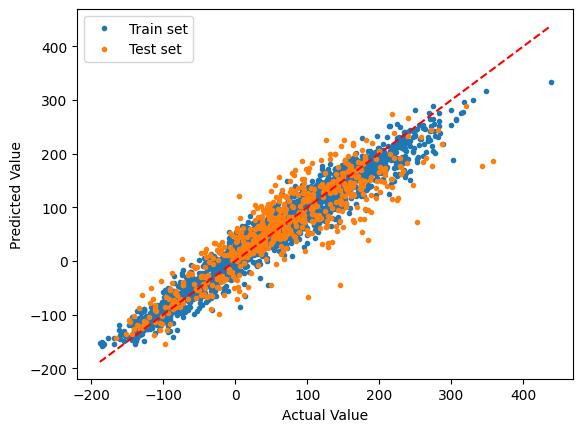

In [24]:
plt.plot(train_y, train_pred,'.',label='Train set')
plt.plot(test_y, test_pred,'.',label='Test set')
# to get a diagonal line
diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
# plt.axline([0, 0], slope=1, color='red', linestyle='--')
plt.legend()
plt.ylabel("Predicted Value")
plt.xlabel("Actual Value")
plt.show()

In [29]:
print(train_X.shape)

(2420, 43)


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

In [32]:
class DeepNet(nn.Module):
    def __init__(self, input_dim: int,
                 output_dim: int = 1,
                 hidden_dim: int = 128,
                 n_layers: int = 6):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

        # Xavier init for faster convergence
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [33]:
input_dim = train_X.shape[1]
print(input_dim)

model = DeepNet(input_dim=input_dim, hidden_dim=128, n_layers=6)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}\n")

43
DeepNet(
  (net): Sequential(
    (0): Linear(in_features=43, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 88,321



In [46]:
train_X_t = torch.tensor(train_X.values, dtype=torch.float32)
train_y_t = torch.tensor(train_y.values, dtype=torch.float32).unsqueeze(1)
test_X_t = torch.tensor(test_X.values, dtype=torch.float32)
test_y_t = torch.tensor(test_y.values, dtype=torch.float32).unsqueeze(1)

In [45]:
print(test_y_t.shape)

torch.Size([605, 1])


In [53]:

EPOCHS    = 20_000
LR        = 1e-3
SCHEDULER_PATIENCE = 300

# ── Regularization config ─────────────────────────────────────────────────────
# Set REG_TYPE to: None | "L1" | "L2" | "ElasticNet"
REG_TYPE   = None      # None | "L1" | "L2" | "ElasticNet"
LAMBDA_L1  = 1e-4       # L1 penalty weight  (used for L1 and ElasticNet)
LAMBDA_L2  = 1e-4       # L2 penalty weight  (used for L2 and ElasticNet)


def regularization_loss(model: nn.Module, reg_type: str | None) -> torch.Tensor:
    """Return the regularization penalty for all weight tensors (biases excluded)."""
    if reg_type is None:
        return torch.tensor(0.0)

    weights = [p for name, p in model.named_parameters() if "weight" in name]

    if reg_type == "L1":
        return LAMBDA_L1 * sum(p.abs().sum() for p in weights)

    if reg_type == "L2":
        return LAMBDA_L2 * sum(p.pow(2).sum() for p in weights)

    if reg_type == "ElasticNet":
        l1 = LAMBDA_L1 * sum(p.abs().sum() for p in weights)
        l2 = LAMBDA_L2 * sum(p.pow(2).sum() for p in weights)
        return l1 + l2

    raise ValueError(f"Unknown reg_type '{reg_type}'. Choose None, 'L1', 'L2', or 'ElasticNet'.")


reg_label = REG_TYPE if REG_TYPE else "None"
print(f"Regularization : {reg_label}")
if REG_TYPE in ("L1", "ElasticNet"):
    print(f"  λ_L1 = {LAMBDA_L1}")
if REG_TYPE in ("L2", "ElasticNet"):
    print(f"  λ_L2 = {LAMBDA_L2}")
print()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=SCHEDULER_PATIENCE, factor=0.5
)

loss_history      = []   # total loss  (MSE + penalty)
mse_history       = []   # data term only
reg_loss_history  = []   # penalty term only

for epoch in range(1, EPOCHS + 1):
    # set the NN to training mode
    model.train()
    # set gradient to zero
    optimizer.zero_grad()

    # calculate the loss
    pred     = model(train_X_t)
    mse_loss = criterion(pred, train_y_t)
    reg_loss = regularization_loss(model, REG_TYPE)
    loss     = mse_loss + reg_loss

    # calculate the gradient of the loss
    loss.backward()
    # update the parameters based on the loss
    optimizer.step()
    scheduler.step(loss)

    #
    loss_history.append(loss.item())
    mse_history.append(mse_loss.item())
    reg_loss_history.append(reg_loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d}/{EPOCHS} | Total: {loss.item():.6f} | "
              f"MSE: {mse_loss.item():.6f} | Reg ({reg_label}): {reg_loss.item():.6f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")




Regularization : None

Epoch   500/20000 | Total: 62.149529 | MSE: 62.149529 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  1000/20000 | Total: 68.430290 | MSE: 68.430290 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  1500/20000 | Total: 63.614845 | MSE: 63.614845 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  2000/20000 | Total: 52.900265 | MSE: 52.900265 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  2500/20000 | Total: 48.319420 | MSE: 48.319420 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  3000/20000 | Total: 63.465378 | MSE: 63.465378 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  3500/20000 | Total: 56.422386 | MSE: 56.422386 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  4000/20000 | Total: 52.158161 | MSE: 52.158161 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  4500/20000 | Total: 43.545696 | MSE: 43.545696 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  5000/20000 | Total: 36.930641 | MSE: 36.930641 | Reg (None): 0.000000 | LR: 5.00e-04
Epoch  5500/20000 | Total: 25.595667 | MSE: 25.595667 | R

In [61]:
model.eval()
with torch.no_grad():
    pred_test_y_t   = model(test_X_t)
    pred_train_y_t   = model(train_X_t)

test_mse = criterion(pred_test_y_t, test_y_t).item()
print(f"\nTest MSE: {test_mse:.6f}")


Test MSE: 3426.502441


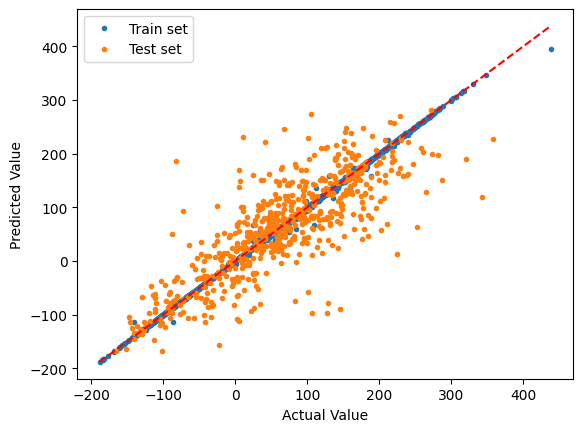

In [62]:
plt.plot(train_y_t, pred_train_y_t,'.',label='Train set')
plt.plot(test_y_t, pred_test_y_t,'.',label='Test set')
# to get a diagonal line
diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
# plt.axline([0, 0], slope=1, color='red', linestyle='--')
plt.legend()
plt.ylabel("Predicted Value")
plt.xlabel("Actual Value")
plt.show()

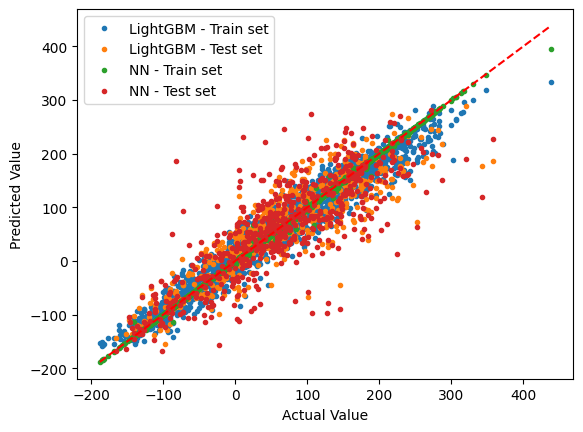

In [57]:
plt.plot(train_y, train_pred,'.',label='LightGBM - Train set')
plt.plot(test_y, test_pred,'.',label='LightGBM - Test set')
plt.plot(train_y_t, pred_train_y_t,'.',label='NN - Train set')
plt.plot(test_y_t, pred_test_y_t,'.',label='NN - Test set')
# to get a diagonal line
diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
# plt.axline([0, 0], slope=1, color='red', linestyle='--')
plt.legend()
plt.ylabel("Predicted Value")
plt.xlabel("Actual Value")
plt.show()

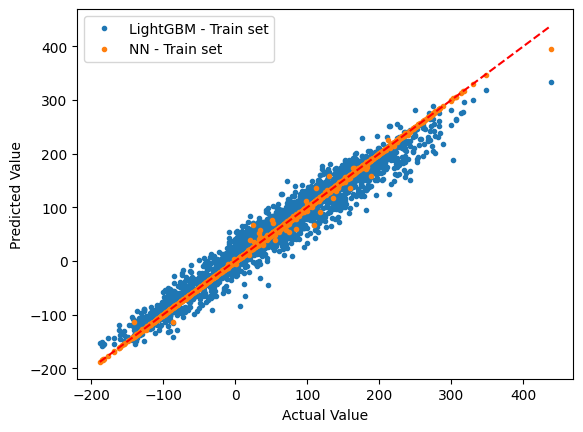

In [58]:
plt.plot(train_y, train_pred,'.',label='LightGBM - Train set')
# plt.plot(test_y, test_pred,'.',label='LightGBM - Test set')
plt.plot(train_y_t, pred_train_y_t,'.',label='NN - Train set')
# plt.plot(test_y_t, pred_test_y_t,'.',label='NN - Test set')
# to get a diagonal line
diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
# plt.axline([0, 0], slope=1, color='red', linestyle='--')
plt.legend()
plt.ylabel("Predicted Value")
plt.xlabel("Actual Value")
plt.show()

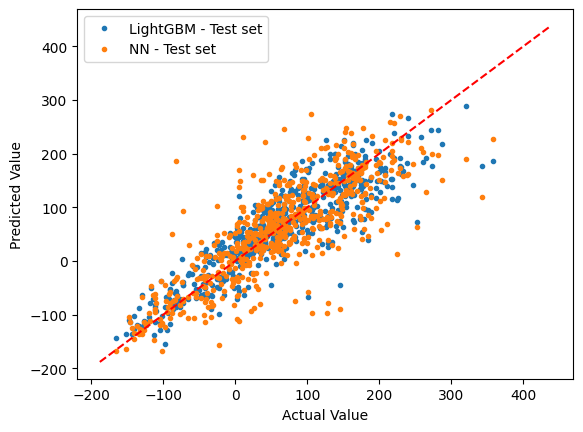

In [59]:
# plt.plot(train_y, train_pred,'.',label='LightGBM - Train set')
plt.plot(test_y, test_pred,'.',label='LightGBM - Test set')
# plt.plot(train_y_t, pred_train_y_t,'.',label='NN - Train set')
plt.plot(test_y_t, pred_test_y_t,'.',label='NN - Test set')
# to get a diagonal line
diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
# plt.axline([0, 0], slope=1, color='red', linestyle='--')
plt.legend()
plt.ylabel("Predicted Value")
plt.xlabel("Actual Value")
plt.show()